In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Unemployment_in_India.csv')
print("Raw Shape:", df.shape)
df.head()

Raw Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df = df.dropna(how='all')

In [4]:
df.columns = df.columns.str.strip()

In [5]:
str_cols = df.select_dtypes(include=['object', 'string']).columns

for col in str_cols:
    df[col] = df[col].str.strip()

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [7]:
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

In [8]:
df['Month'] = df['Date'].dt.month_name()

df['Month_Num'] = df['Date'].dt.month

df['Year'] = df['Date'].dt.year

df['Year_Month'] = df['Date'].dt.to_period('M')

In [9]:
df

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Month_Num,Year,Year_Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,5,2019,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,6,2019,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,7,2019,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,8,2019,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,9,2019,2019-09
...,...,...,...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban,February,2,2020,2020-02
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban,March,3,2020,2020-03
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban,April,4,2020,2020-04
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban,May,5,2020,2020-05


In [10]:
print("Cleaned shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDate range:")
print(df['Date'].min().date(), "to", df['Date'].max().date())

print("\nNumber of Regions:")
print(df['Region'].nunique())

print("\nAreas:")
print(df['Area'].unique())

Cleaned shape: (740, 11)

Missing values:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
Month                        0
Month_Num                    0
Year                         0
Year_Month                   0
dtype: int64

Duplicate rows:
0

Date range:
2019-05-31 to 2020-06-30

Number of Regions:
28

Areas:
<StringArray>
['Rural', 'Urban']
Length: 2, dtype: str


In [11]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Month_Num,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


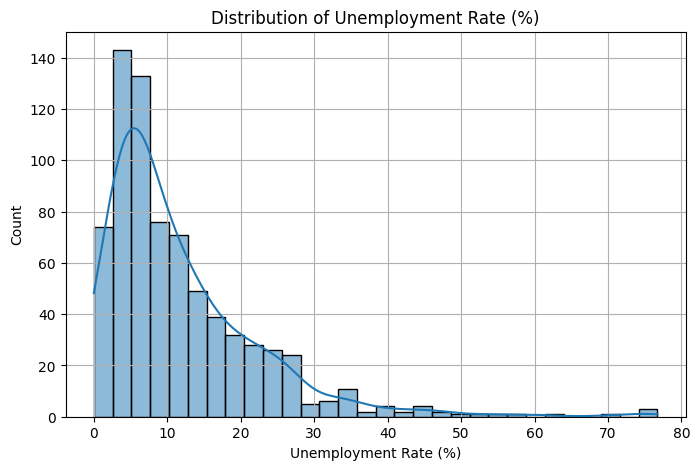

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Unemployment_Rate'],
    bins=30,
    kde=True
)

plt.title('Distribution of Unemployment Rate (%)')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Count')
plt.grid()

plt.show()

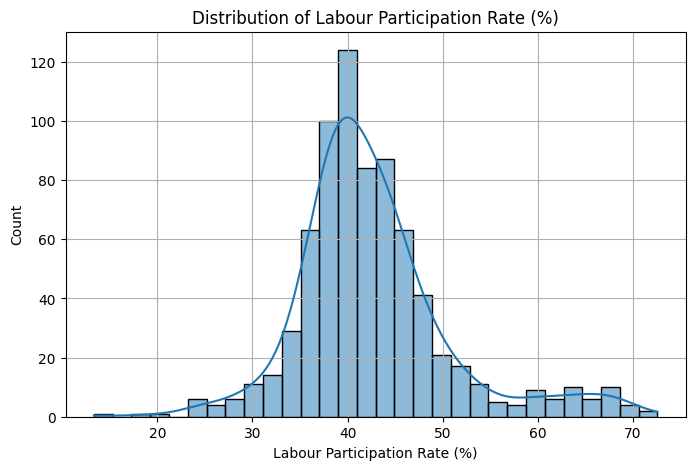

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Labour_Participation_Rate'],
    bins=30,
    kde=True
)

plt.title('Distribution of Labour Participation Rate (%)')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Count')
plt.grid()

plt.show()

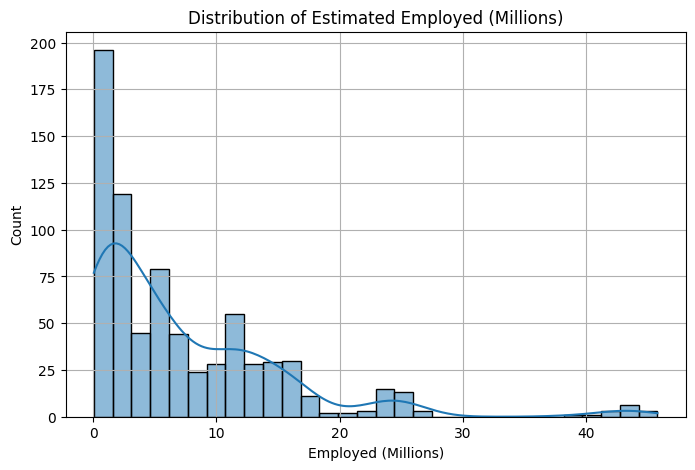

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Employed'] / 1e6,
    bins=30,
    kde=True
)

plt.title('Distribution of Estimated Employed (Millions)')
plt.xlabel('Employed (Millions)')
plt.ylabel('Count')
plt.grid()

plt.show()

In [15]:
national_trend = df.groupby('Date').agg({
    'Unemployment_Rate': 'mean',
    'Labour_Participation_Rate': 'mean',
    'Employed': 'sum'
}).reset_index()

print(national_trend.head())

        Date  Unemployment_Rate  Labour_Participation_Rate     Employed
0 2019-05-31           8.874259                  43.902963  400148016.0
1 2019-06-30           9.303333                  43.750556  397366645.0
2 2019-07-31           9.033889                  43.706667  399838967.0
3 2019-08-31           9.637925                  43.646792  399610205.0
4 2019-09-30           9.051731                  44.301346  402452126.0


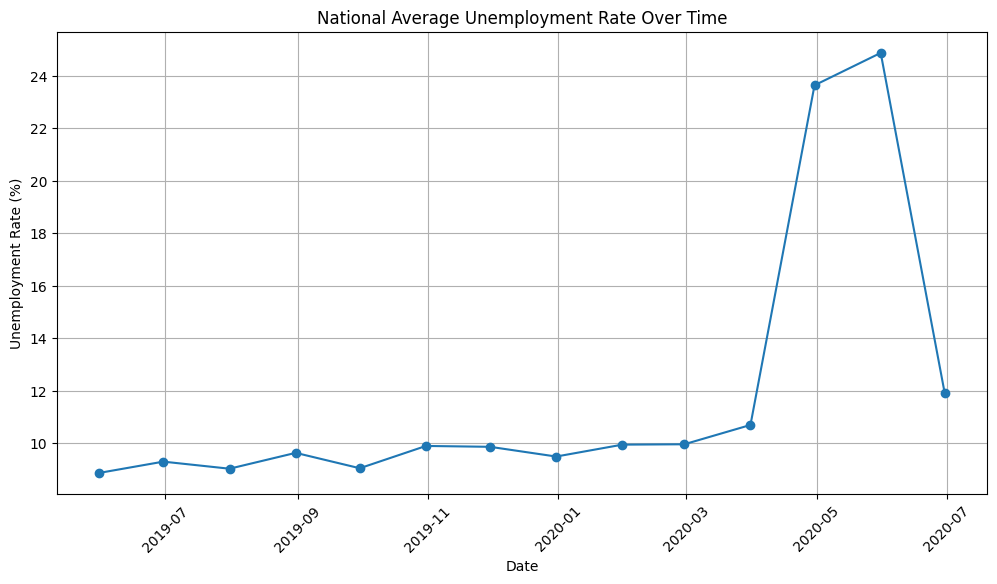

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    national_trend['Date'],
    national_trend['Unemployment_Rate'],
    marker='o'
)

plt.title('National Average Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.grid()

plt.show()

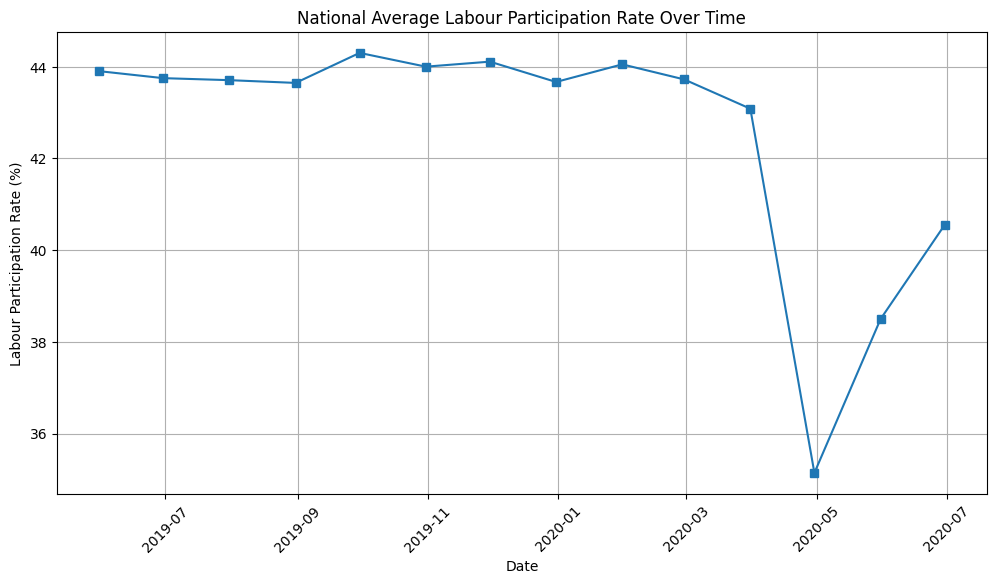

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    national_trend['Date'],
    national_trend['Labour_Participation_Rate'],
    marker='s'
)

plt.title('National Average Labour Participation Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Labour Participation Rate (%)')

plt.xticks(rotation=45)
plt.grid()

plt.show()

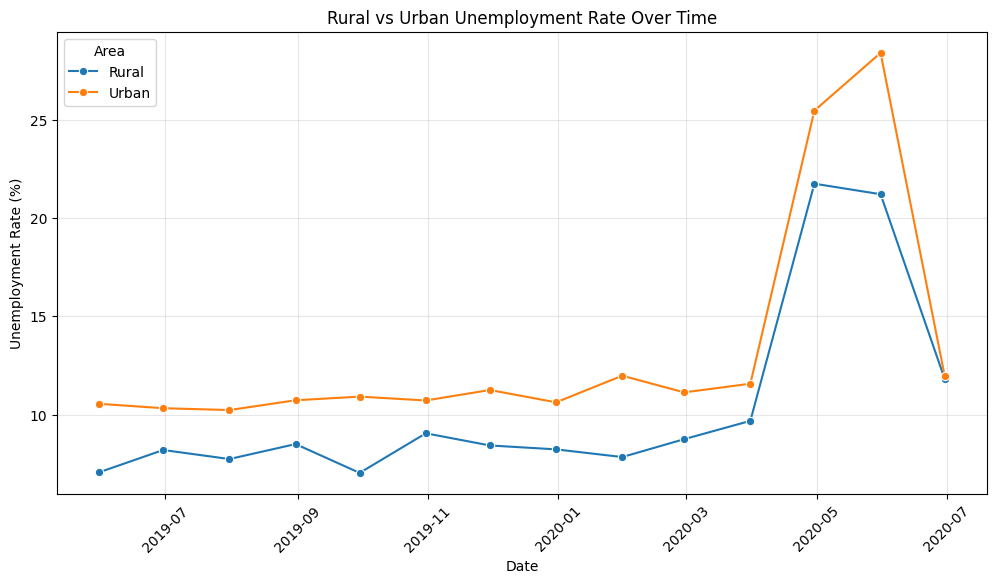

In [18]:
area_trend = df.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=area_trend,
    x='Date',
    y='Unemployment_Rate',
    hue='Area',
    marker='o'
)

plt.title('Rural vs Urban Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

# Add grid
plt.grid(alpha=0.3)

# Rotate date labels
plt.xticks(rotation=45)

# Show the graph
plt.show()

In [19]:
pre_covid = df[df['Date'] < '2020-03-01']

pre_covid.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Month_Num,Year,Year_Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,5,2019,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,6,2019,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,7,2019,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,8,2019,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,9,2019,2019-09


In [20]:
covid_period = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-06-30')
]

covid_period.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Month_Num,Year,Year_Month
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural,March,3,2020,2020-03
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural,April,4,2020,2020-04
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural,May,5,2020,2020-05
13,Andhra Pradesh,2020-06-30,Monthly,0.85,15572975.0,53.76,Rural,June,6,2020,2020-06
23,Assam,2020-03-31,Monthly,3.77,9878742.0,47.05,Rural,March,3,2020,2020-03


In [21]:
pre_unemployment = pre_covid['Unemployment_Rate'].mean()

pre_employed = (
    pre_covid['Employed'].sum()
    / pre_covid['Date'].nunique()
    / 1e6
)

pre_labour = pre_covid['Labour_Participation_Rate'].mean()

print("Pre-COVID Unemployment:", pre_unemployment)
print("Pre-COVID Employed (Millions):", pre_employed)
print("Pre-COVID Labour Participation:", pre_labour)

Pre-COVID Unemployment: 9.509533582089553
Pre-COVID Employed (Millions): 400.17909380000003
Pre-COVID Labour Participation: 43.886119402985074


In [22]:
covid_unemployment = covid_period['Unemployment_Rate'].mean()

covid_employed = (
    covid_period['Employed'].sum()
    / covid_period['Date'].nunique()
    / 1e6
)

covid_labour = covid_period['Labour_Participation_Rate'].mean()

print("COVID Unemployment:", covid_unemployment)
print("COVID Employed (Millions):", covid_employed)
print("COVID Labour Participation:", covid_labour)

COVID Unemployment: 17.774362745098042
COVID Employed (Millions): 332.37737025
COVID Labour Participation: 39.33004901960784


In [23]:
comparison = pd.DataFrame({
    'Pre-COVID': [
        pre_unemployment,
        pre_employed,
        pre_labour
    ],
    
    'COVID Period': [
        covid_unemployment,
        covid_employed,
        covid_labour
    ]
}, index=[
    'Avg Unemployment Rate (%)',
    'Avg Monthly Employed (Millions)',
    'Avg Labour Participation (%)'
])

comparison

,Pre-COVID,COVID Period
Avg Unemployment Rate (%),9.509534,17.774363
Avg Monthly Employed (Millions),400.179094,332.377370
Avg Labour Participation (%),43.886119,39.330049


In [24]:
comparison['% Change'] = (
    (comparison['COVID Period'] - comparison['Pre-COVID'])
    / comparison['Pre-COVID']
) * 100

comparison = comparison.round(2)
comparison

,Pre-COVID,COVID Period,% Change
Avg Unemployment Rate (%),9.51,17.77,86.91
Avg Monthly Employed (Millions),400.18,332.38,-16.94
Avg Labour Participation (%),43.89,39.33,-10.38


In [25]:
monthly_national = df.groupby('Year_Month')['Unemployment_Rate'].mean()

monthly_national

Year_Month
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Unemployment_Rate, dtype: float64

In [26]:
colors = []

for month in monthly_national.index:
    if str(month) >= '2020-03':
        colors.append('red')       
    else:
        colors.append('blue')      


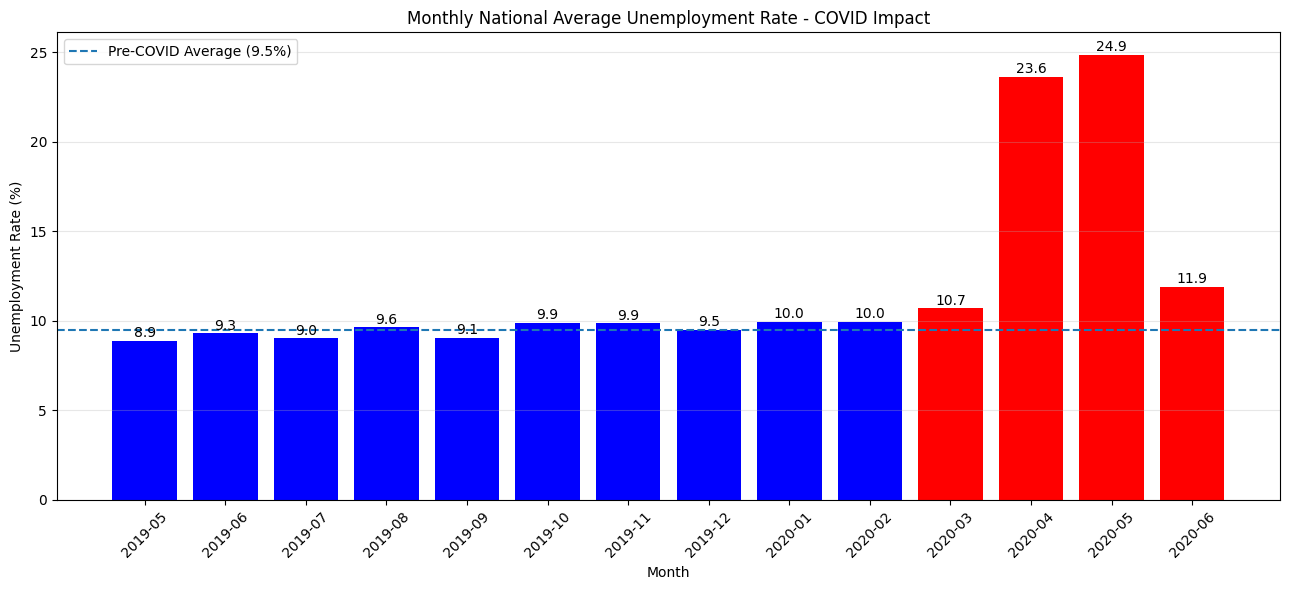

In [27]:
pre_covid_average = pre_covid['Unemployment_Rate'].mean()


plt.figure(figsize=(13, 6))

bars = plt.bar(
    monthly_national.index.astype(str),
    monthly_national.values,
    color=colors
)
plt.axhline(
    pre_covid_average,
    linestyle='--',
    label=f'Pre-COVID Average ({pre_covid_average:.1f}%)'
)

for bar, value in zip(bars, monthly_national.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f'{value:.1f}',
        ha='center'
    )

plt.title('Monthly National Average Unemployment Rate - COVID Impact')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
peak_month = monthly_national.idxmax()

peak_value = monthly_national.max()

pre_covid_average = pre_covid['Unemployment_Rate'].mean()

increase = peak_value - pre_covid_average

percentage_increase = (increase / pre_covid_average) * 100

print("Peak unemployment month:", peak_month)
print("Peak unemployment rate:", round(peak_value, 2), "%")

print("Pre-COVID average:", round(pre_covid_average, 2), "%")

print("Increase at peak:", round(increase, 2), "percentage points")
print("Relative increase:", round(percentage_increase, 0), "%")

Peak unemployment month: 2020-05
Peak unemployment rate: 24.88 %
Pre-COVID average: 9.51 %
Increase at peak: 15.37 percentage points
Relative increase: 162.0 %


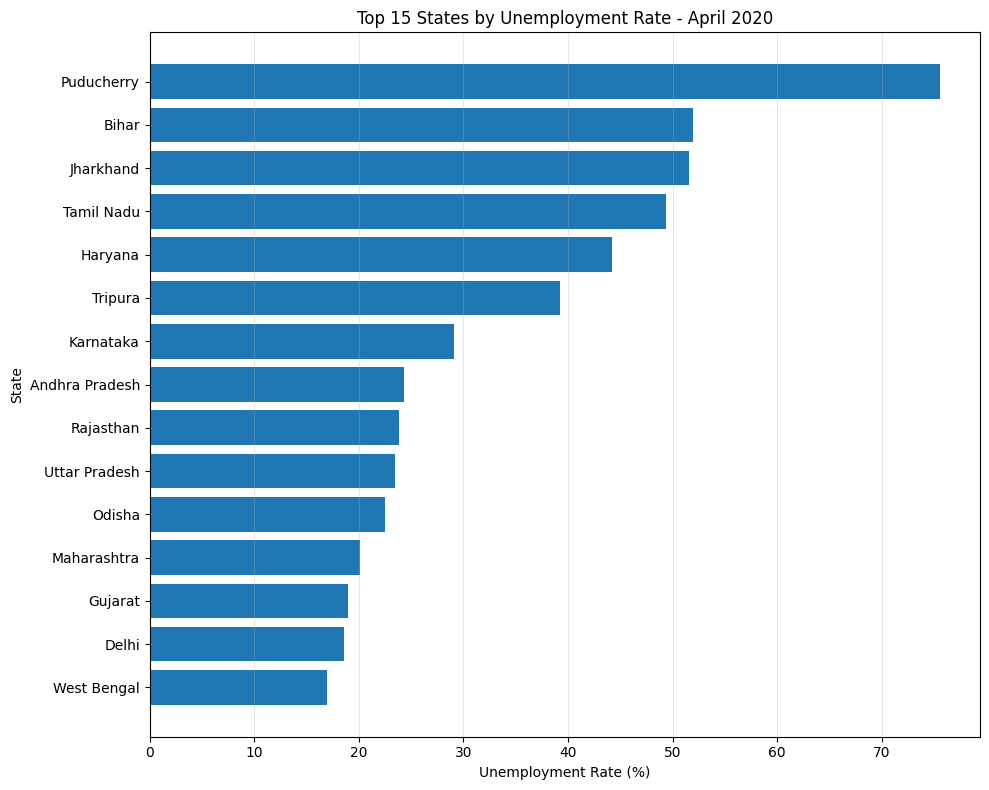

Top 10 States:
Region
Puducherry        75.62
Bihar             51.93
Jharkhand         51.60
Tamil Nadu        49.37
Haryana           44.25
Tripura           39.26
Karnataka         29.15
Andhra Pradesh    24.30
Rajasthan         23.89
Uttar Pradesh     23.43
Name: Unemployment_Rate, dtype: float64


In [29]:
april_2020 = df[df['Year_Month'] == '2020-04']

april_2020 = april_2020.groupby('Region')['Unemployment_Rate'].mean()

april_2020 = april_2020.sort_values(ascending=False)

top_15 = april_2020.head(15)

plt.figure(figsize=(10, 8))
plt.barh(
    top_15.index[::-1],
    top_15.values[::-1]
)
plt.title('Top 15 States by Unemployment Rate - April 2020')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("Top 10 States:")
print(april_2020.head(10).round(2))

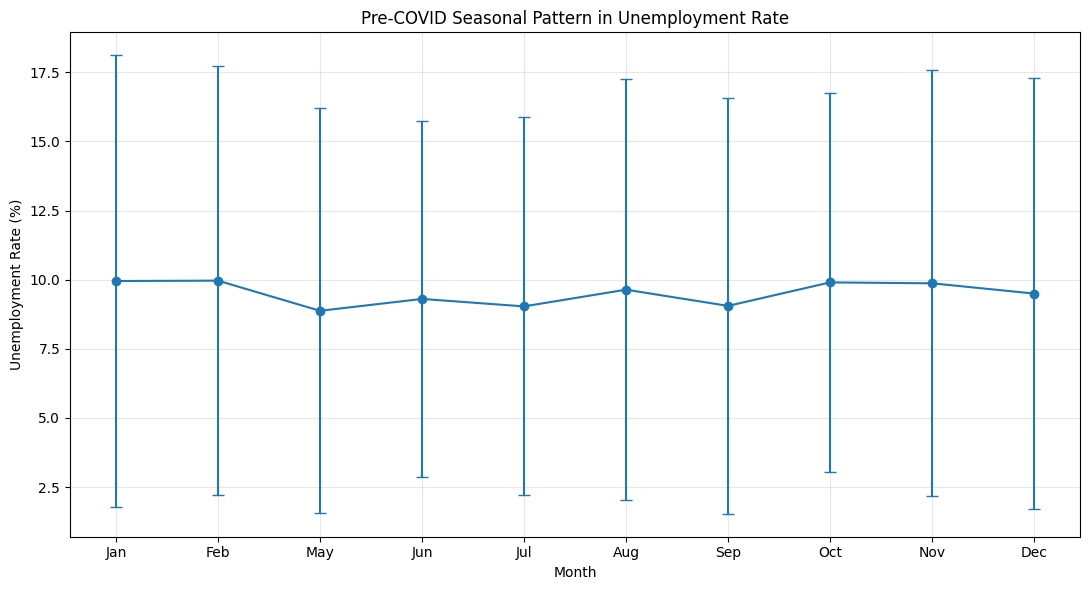

In [30]:
seasonal = df[df['Date'] < '2020-03-01']

seasonal = seasonal.groupby('Month_Num')['Unemployment_Rate'].agg(['mean', 'std'])

seasonal = seasonal.reset_index()

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

seasonal['Month'] = seasonal['Month_Num'].apply(
    lambda x: month_names[x - 1]
)

seasonal = seasonal.sort_values('Month_Num')

plt.figure(figsize=(11, 6))
plt.errorbar(
    seasonal['Month'],
    seasonal['mean'],
    yerr=seasonal['std'],
    marker='o',
    capsize=4
)
plt.title('Pre-COVID Seasonal Pattern in Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

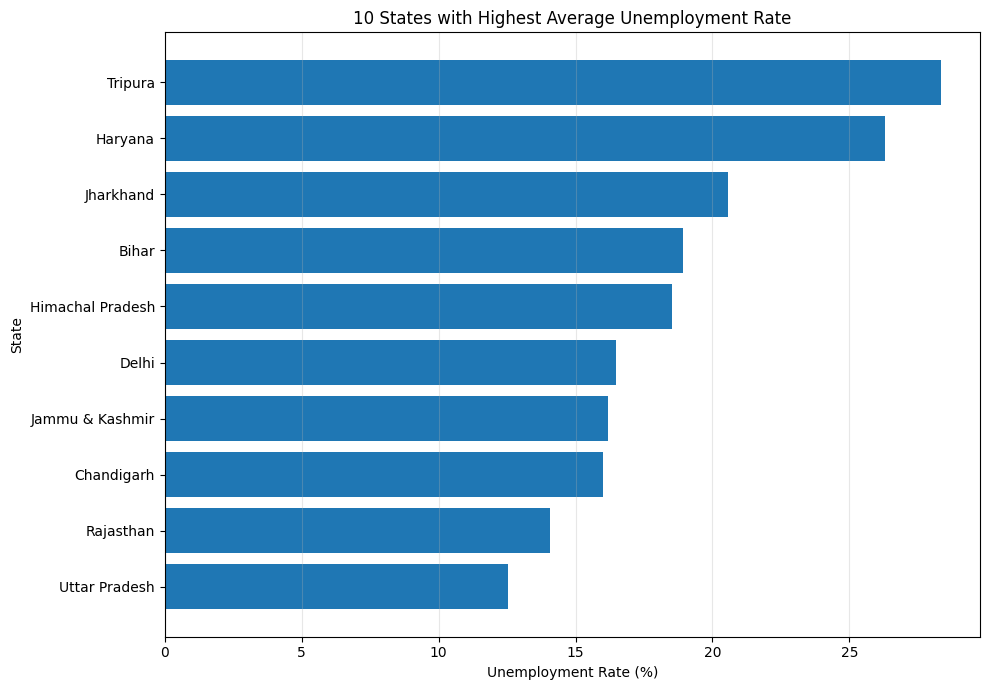

In [31]:
state_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

top10 = state_avg.head(10)
bottom10 = state_avg.tail(10)

plt.figure(figsize=(10, 7))
plt.barh(top10.index[::-1], top10.values[::-1])
plt.title('10 States with Highest Average Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

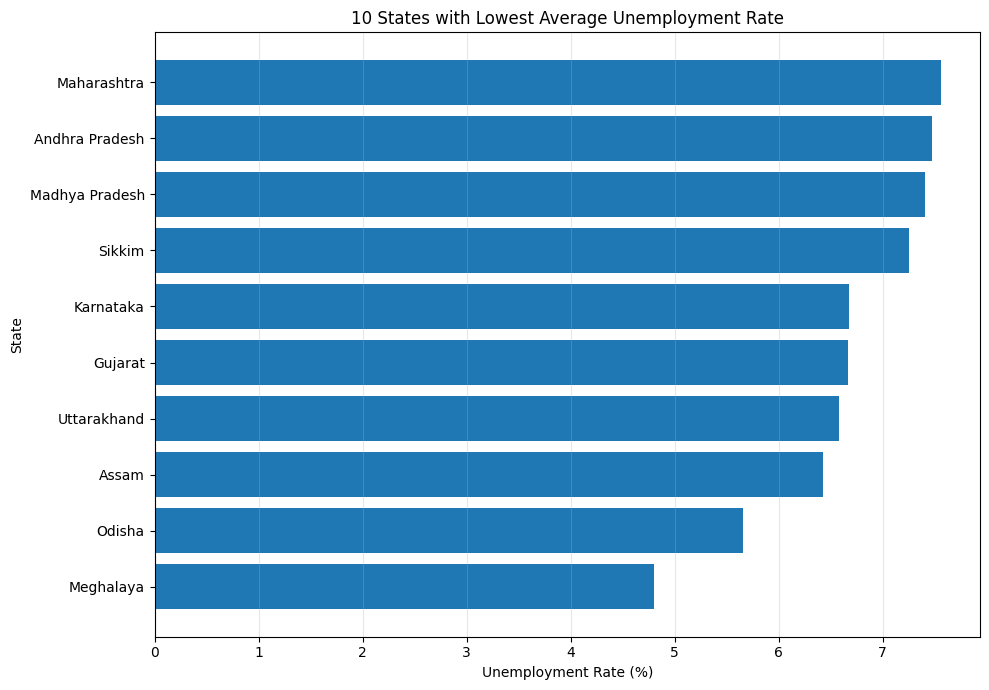

In [32]:
plt.figure(figsize=(10, 7))
plt.barh(bottom10.index[::-1], bottom10.values[::-1])
plt.title('10 States with Lowest Average Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('State')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

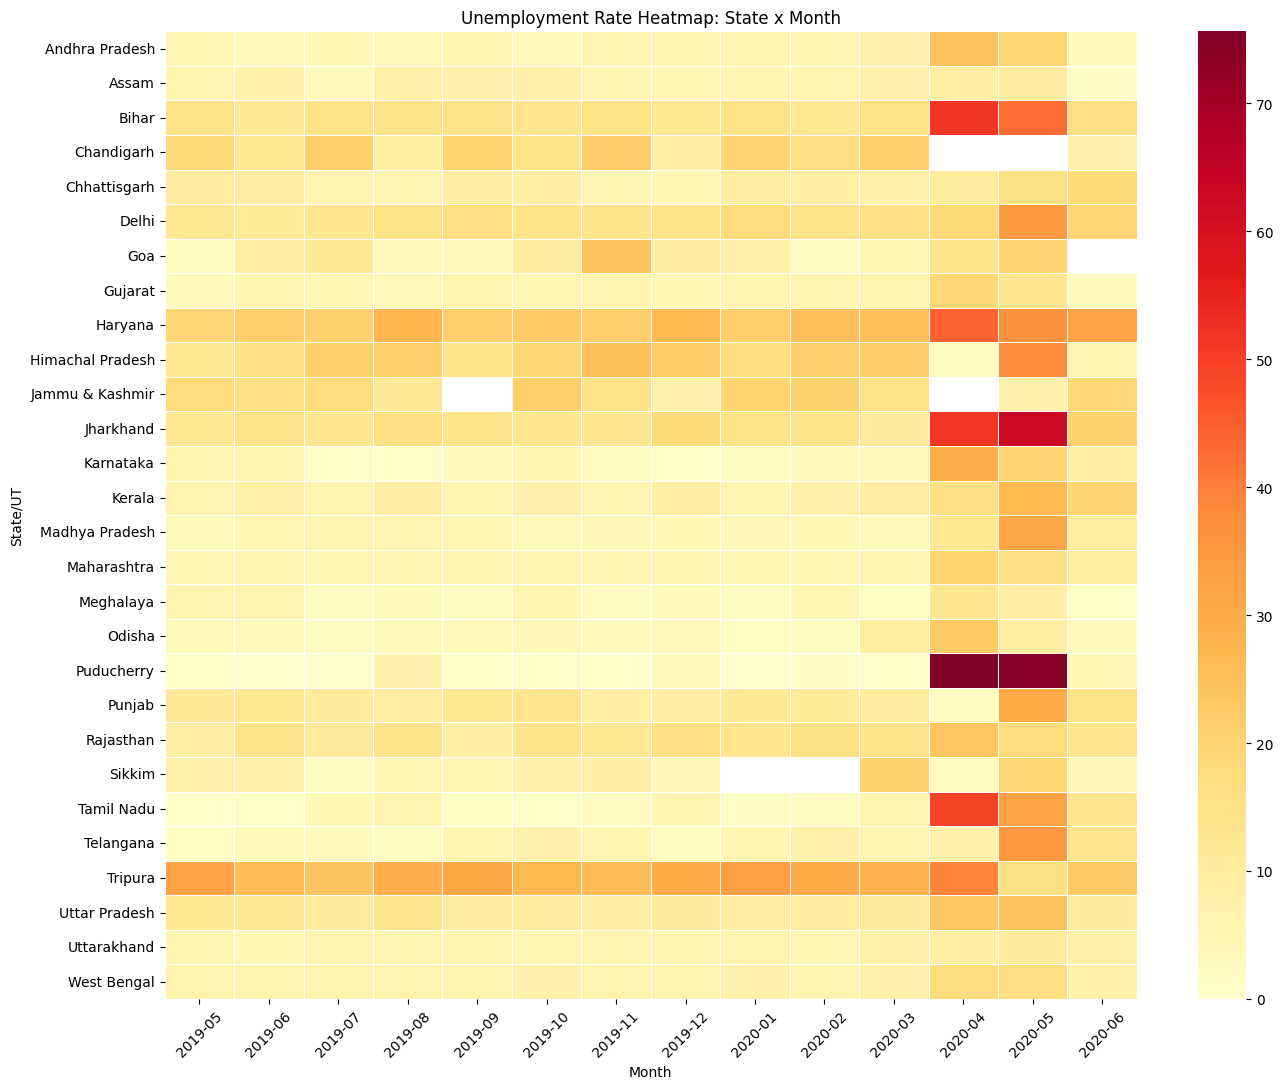

In [33]:
pivot = df.pivot_table(
    index='Region',
    columns='Year_Month',
    values='Unemployment_Rate',
    aggfunc='mean'
)

pivot.columns = pivot.columns.astype(str)

plt.figure(figsize=(14, 11))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white'
)
plt.title('Unemployment Rate Heatmap: State x Month')
plt.xlabel('Month')
plt.ylabel('State/UT')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

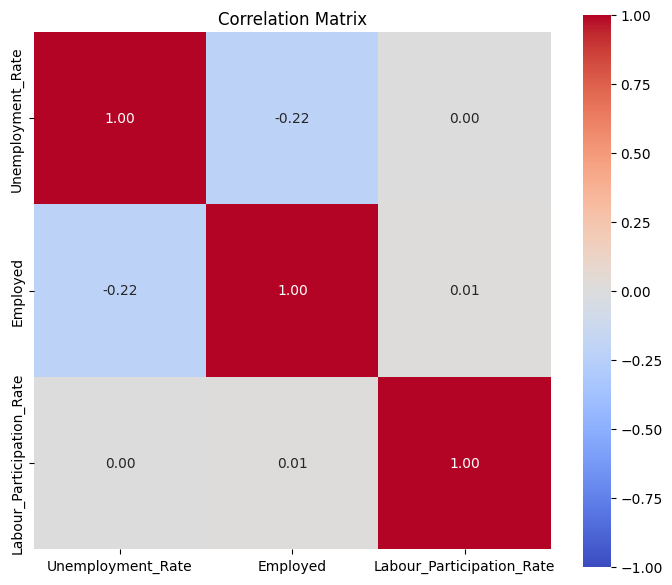

In [34]:
corr_cols = [
    'Unemployment_Rate',
    'Employed',
    'Labour_Participation_Rate'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    square=True
)
plt.title('Correlation Matrix')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


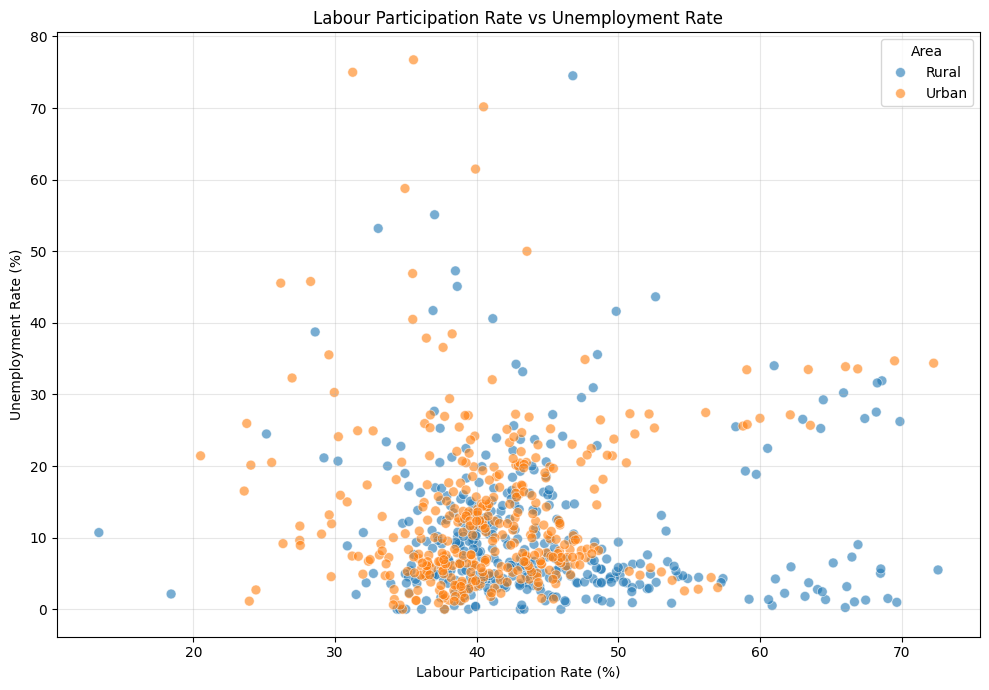

In [35]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Labour_Participation_Rate',
    y='Unemployment_Rate',
    hue='Area',
    alpha=0.6,
    s=50
)
plt.title('Labour Participation Rate vs Unemployment Rate')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()